# Franck-Hertz (Mercury) analysis pipeline

Thin driver around `pipeline.py`. Validate on **Run 1** first, then expand to all runs and cross-compare.

Stages: load → denoise → downsample → plot I-vs-V → find maxima → plot maxima → peak spacings.
All knobs live in `pipeline.CONFIG`.

In [6]:
import importlib
import pipeline
importlib.reload(pipeline)  # re-run this cell after editing pipeline.py
from pipeline import (CONFIG, run_pipeline, load_run, denoise, downsample,
                      plot_iv, find_fh_peaks, plot_overlay,
                      combined_fit, plot_combined_fit, plot_contact_corrected)

# Show inline in the notebook in addition to saving PNGs
%matplotlib inline
CONFIG["show"] = True

## Config toggles
Adjust here, then re-run the cells below. Each stage can be turned off independently.

In [ ]:
# ===================== DATASET SELECTOR =====================
# Flip this one switch; everything below is set consistently for that gas.
DATASET = "Mercury"          # "Mercury" or "Neon"

if DATASET == "Mercury":     # Siglent scope, 100k pts/run, 6 runs
    CONFIG["data_root"] = "Mercury Data"
    CONFIG["save_dir"]  = "outputs"
    CONFIG["downsample"].update(enabled=True, method="random", fraction=0.10)
    CONFIG["peaks"].update(median_window=51, smooth_window=401, min_distance=30, prominence=None)
    CONFIG["v_calibration"] = {"default": 10.0, "Run 1": 5.0}   # Run 1 at 5x
    CONFIG["peak_index"]    = {"default": 1,    "Run 1": 2}      # Run 1 missed 1st peak
    CONFIG["element"], CONFIG["literature_dv"] = "Hg", 4.9
elif DATASET == "Neon":      # Tektronix scope, ~2.5k pts/run
    CONFIG["data_root"] = "Neon Data"
    CONFIG["save_dir"]  = "Neon Data Outputs"
    CONFIG["downsample"].update(enabled=False)                  # only ~2.5k pts, no thinning
    CONFIG["peaks"].update(median_window=7, smooth_window=41, min_distance=40, prominence=0.15)
    CONFIG["v_calibration"] = {"default": 10.0}
    CONFIG["peak_index"]    = {"default": 1}
    CONFIG["element"], CONFIG["literature_dv"] = "Ne", 18.7

# ===================== shared knobs =====================
# noise removal
CONFIG["denoise"].update(enabled=True, window=75, threshold_pct=3.0,
                         mode="narrow_spikes", max_spike_width=40)

# calibration uncertainty: scope vertical-gain accuracy (systematic; ~0.05% scope
# resolution means precision is tiny, so this is the floor). 0.2% assumed.
CONFIG["v_calibration_rel_err"] = 0.002

# uncertainty propagation: bootstrap the cleaning+sampling n times for per-peak
# 1-sigma, carried into the weighted shared-slope fit (0 disables).
CONFIG["uncertainty"] = {"n_bootstrap": 200, "seed": 12345}

print(f"configured for {DATASET}: data_root={CONFIG['data_root']!r}, save_dir={CONFIG['save_dir']!r}")

## 1-2. Raw vs denoised (Run 1)

c:\Users\donal\Desktop\School\PHY-353L\Franck-Hertz\pipeline.py:211: RuntimeWarning: All-NaN slice encountered
  irange = float(np.nanmax(y) - np.nanmin(y)) or 1.0


raw: 2482  ->  denoised: 2482  (100.0% kept)


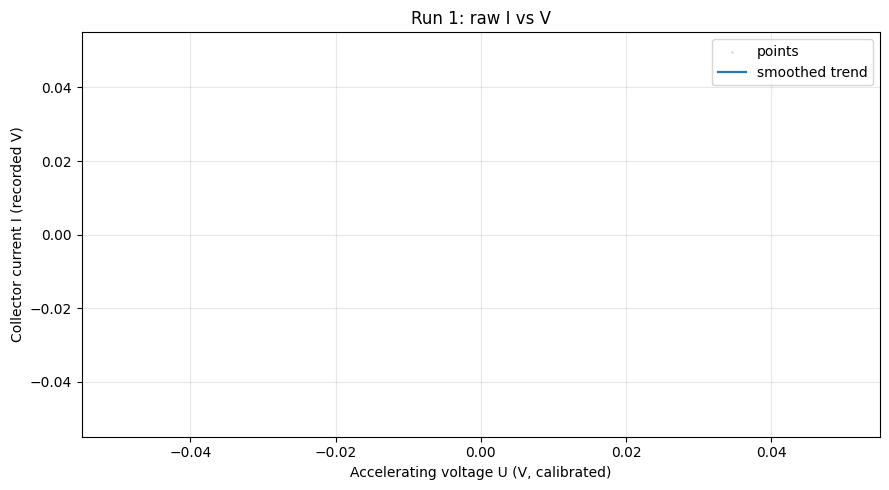

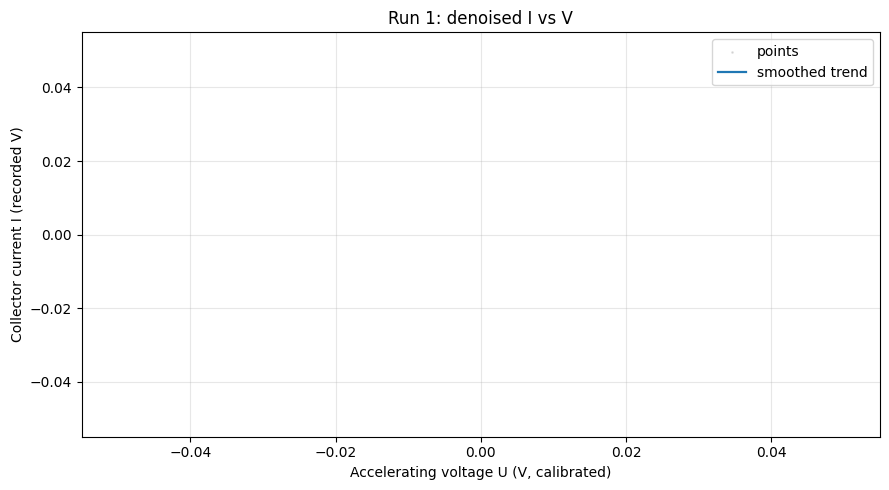

In [9]:
RUN = "Run 1"
raw = load_run(RUN)
den = denoise(raw)
print(f"raw: {len(raw)}  ->  denoised: {len(den)}  ({100*len(den)/len(raw):.1f}% kept)")
_ = plot_iv(raw, RUN, tag="raw", title=f"{RUN}: raw I vs V")
_ = plot_iv(den, RUN, tag="denoised", title=f"{RUN}: denoised I vs V")

## 3-7. Full pipeline (Run 1)

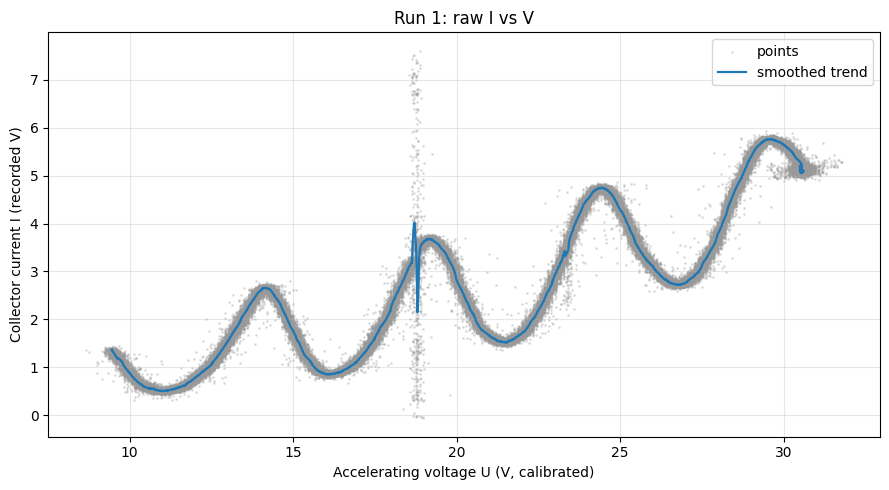

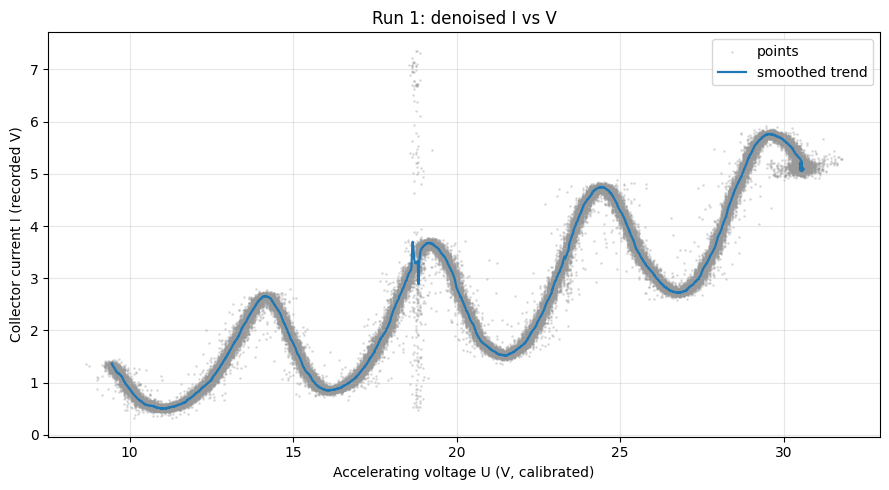

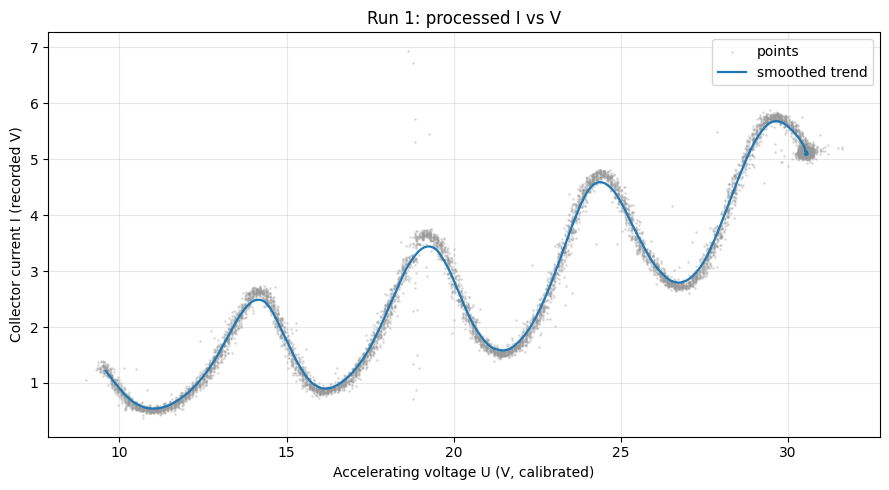

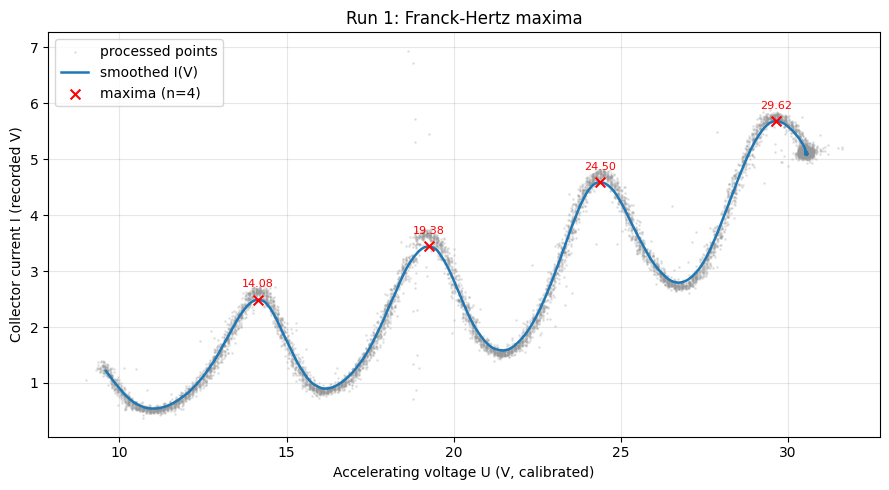

Run: Run 1
  raw points       : 100000
  after processing : 9963 (10.0%)
  peaks found      : 4
  peak V (recorded): 2.817, 3.875, 4.900, 5.925
  spacings (rec. V): 1.058, 1.025, 1.025
  mean spacing     : 1.036 +/- 0.019 V (recorded)
  mean spacing     : 5.181 V (calibrated, x5.0)


In [22]:
res = run_pipeline(RUN, plots=True)
print(res.summary())

## Cross-compare all runs
Run once the Run 1 pipeline looks right. This generates the four graphs for every run into `outputs/<Run N>/` (inline display is suppressed here to avoid 24 figures; re-open the PNGs from the folders).

In [23]:
import glob, os
import numpy as np

runs = sorted(d for d in glob.glob(os.path.join(CONFIG["data_root"], "*")) if os.path.isdir(d))

# generate per-run folders (4 graphs each) without flooding the notebook with figures
_show = CONFIG["show"]; CONFIG["show"] = False
results = {os.path.basename(r): run_pipeline(r, plots=True) for r in runs}
CONFIG["show"] = _show

print(f"{'run':8s} {'peaks':>5s} {'spacing (recorded V)':>22s} {'spacing (true V)':>18s}")
for name, r in results.items():
    sp = r.spacings_recorded
    mean = sp.mean() if len(sp) else float("nan")
    std  = sp.std(ddof=1) if len(sp) > 1 else 0.0
    cal_mean = r.spacings_calibrated.mean() if len(sp) else float("nan")
    tail = f"{cal_mean:.3f} (x{r.v_factor})" if r.v_factor != 1.0 else "-- (set factor)"
    print(f"{name:8s} {len(r.peaks_v):5d}   {mean:.3f} +/- {std:.3f}      {tail:>18s}")
print(f"\nper-run graphs written to: {CONFIG['save_dir']}/<run>/  (1_raw, 2_denoised, 3_processed, 4_peaks)")

run      peaks   spacing (recorded V)   spacing (true V)
Run 1        4   1.036 +/- 0.019            5.181 (x5.0)
Run 2        4   0.507 +/- 0.016           5.069 (x10.0)
Run 3        4   0.506 +/- 0.014           5.063 (x10.0)
Run 4        4   0.506 +/- 0.006           5.062 (x10.0)
Run 5        4   0.502 +/- 0.013           5.021 (x10.0)
Run 6        4   0.510 +/- 0.011           5.097 (x10.0)

per-run graphs written to: outputs/<run>/  (1_raw, 2_denoised, 3_processed, 4_peaks)


## Combined overlay (all runs, calibrated)
All six calibrated curves on one axis. `normalize=True` scales each curve's current to [0, 1] so the shapes line up despite different current scales (best for comparing peak positions); set `normalize=False` to keep raw current.

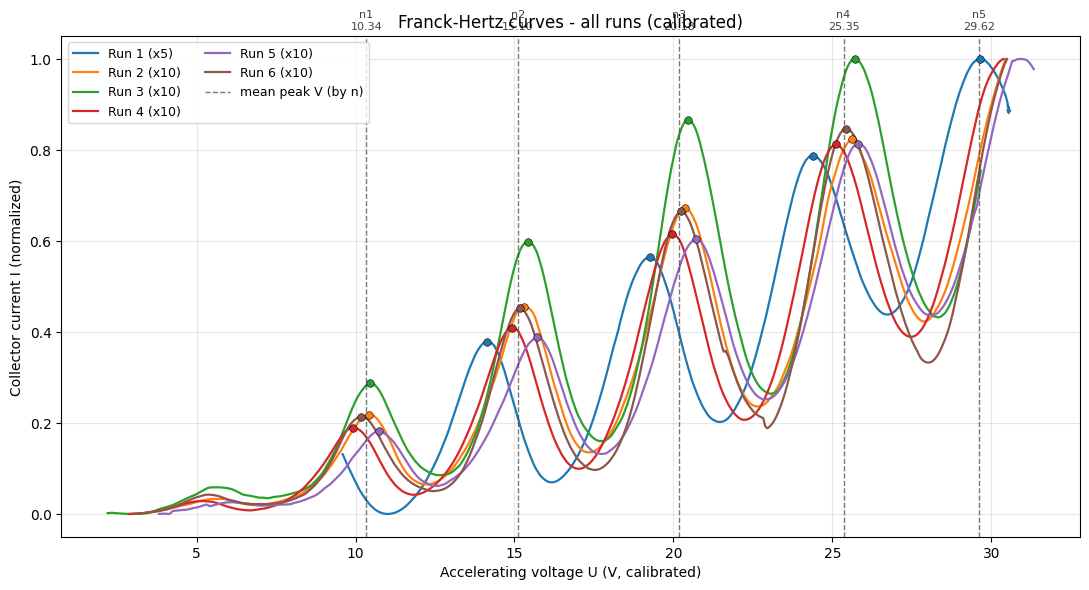

overlay written: outputs\all_runs_overlay.png  (6 runs: Run 1, Run 2, Run 3, Run 4, Run 5, Run 6)


In [24]:
overlay_path = plot_overlay(results, normalize=True)   # set normalize=False for raw current
print(f"overlay written: {overlay_path}  ({len(results)} runs: {', '.join(results)})")

## Combined fit + contact-potential correction
**Shared-slope fit**: one common excitation energy ΔV across all runs, with a separate intercept (contact-potential offset V₀) per run — the right model since runs share ΔV but differ in offset. The **contact-corrected overlay** subtracts each run's V₀ so peaks land on integer multiples of ΔV.

In [ ]:
fit = combined_fit(results)
_elem = CONFIG.get("element", ""); _lit = CONFIG.get("literature_dv", 4.9)
print(f"shared DV (excitation) = {fit['slope']:.3f} V   [{fit['fit_mode']} fit]")
print(f"   sampling/cleaning (bootstrap) = +/- {fit['slope_err_meas']:.3f} V")
if fit['fit_mode'] == 'weighted':
    print(f"   chi2/dof = {fit['chi2_dof']:.2f}  -> Birge inflation x{fit['birge']:.2f} (run-to-run scatter)")
print(f"   statistical (scatter-inflated) = +/- {fit['slope_err']:.3f} V")
print(f"   calibration (systematic)       = +/- {fit['slope_cal_err']:.3f} V")
print(f"   TOTAL (quadrature)             = +/- {fit['slope_total_err']:.3f} V")
print(f"   -> DV = {fit['slope']:.3f} +/- {fit['slope_total_err']:.3f} V   ({_elem} literature {_lit} V)")
print("per-run contact-potential offset V0:")
for name, off in fit["offsets"].items():
    print(f"   {name}: {off:.3f} V")

plot_combined_fit(results)            # peak voltage vs n, shared-slope fit (with error bars)
plot_contact_corrected(results)       # overlay shifted by V0; peaks on n*DV

### Voltage uncertainty from scope resolution
The CSV values are quantized at the scope's vertical resolution. We measure that step directly from the data, convert to true volts, and show how the total ΔV error depends on the assumed scope gain accuracy (the only non-averaging term).

In [ ]:
# measured quantization step of the recorded voltage (channel 1)
raw_v = load_run("Run 1")["V"].to_numpy()
step = np.min(np.diff(np.unique(raw_v)))
fac = CONFIG["v_calibration"].get("default", 1.0)
print(f"scope resolution: {step*1000:.2f} mV recorded  ->  {step*fac*1000:.1f} mV true (x{fac:g})")
print("(precision; already inside the bootstrap/fit error -- the gain accuracy below is the systematic floor)\n")

base = combined_fit(results)
print(f"DV = {base['slope']:.3f} V")
print(f"   sampling/cleaning (bootstrap)  = +/- {base['slope_err_meas']:.3f} V")
print(f"   statistical (scatter-inflated) = +/- {base['slope_err']:.3f} V")
print("total DV error vs. assumed scope gain accuracy:")
for rel in (0.001, 0.002, 0.005, 0.02):
    cal = rel * base["slope"]
    print(f"   {rel*100:>4.1f}%  ->  cal +/- {cal:.3f} V   total +/- {np.hypot(base['slope_err'], cal):.3f} V")

## Test: all runs vs. omitting Run 1
Run 1 was taken at a different scope scale and missed its first maximum (its peaks are indexed n=2..5). Compare the shared-slope fit with and without it to see which is cleaner.

In [ ]:
results_no1 = {k: v for k, v in results.items() if k != "Run 1"}
do_omit = 1 <= len(results_no1) < len(results)   # only meaningful with multiple runs (Mercury)

datasets = [("ALL", results)] + ([("OMIT Run 1", results_no1)] if do_omit else [])
print(f"{'dataset':18s} {'DV +/- stat +/- cal':>26s} {'total':>8s} {'RMS':>7s} {'runs':>5s}")
for label, res in datasets:
    f = combined_fit(res)
    print(f"{label:18s} {f['slope']:.3f} +/- {f['slope_err']:.3f} +/- {f['slope_cal_err']:.3f}   "
          f"+/-{f['slope_total_err']:.3f}   {f['rms_resid']:.3f}   {len(res):>5d}")

if do_omit:
    plot_overlay(results_no1, tag="overlay_no_run1")
    plot_combined_fit(results_no1, tag="_no_run1")
    plot_contact_corrected(results_no1, tag="_no_run1")
    print("\nwrote *_no_run1 figures to", CONFIG["save_dir"])
else:
    print("(single run -> omit-Run-1 comparison skipped)")